## **Python Implementation**

In this section, we implement the TMM algorithm using the `tmmax` library, which is designed for high-performance multilayer simulations with vectorized operations using the `jax` library.

In [ ]:
!pip install tmmax

![title](../_static/logo_tmmax.png)

# **Visualizing Refractive Index and Extinction Coefficient Data**


In [ ]:
import jax.numpy as jnp
from tmmax.data import visualize_material_properties
import matplotlib.pyplot as plt

 ### **Refractive Index and Extinction Coefficient as a Function of Wavelength**

 As of May 6, 2025, the visualizations of all materials available in the tmmax database are provided below. We can visualize the refractive index (n) and extinction coefficient (k) as a function of wavelength. This uses data from the internal nk database and plots it with dual y-axes (n on left, k on right)

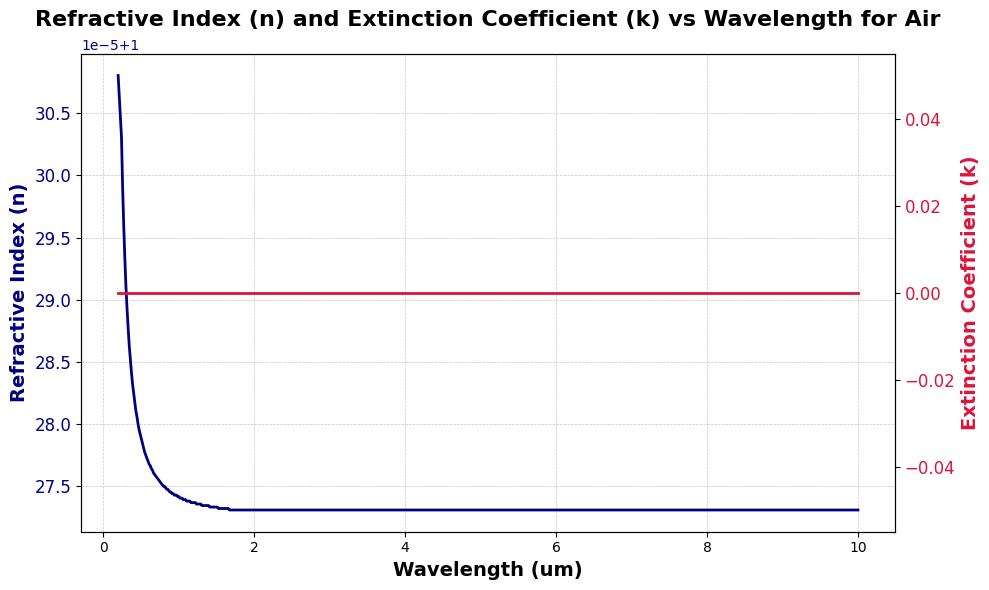

In [ ]:
visualize_material_properties(material_name = "Air")

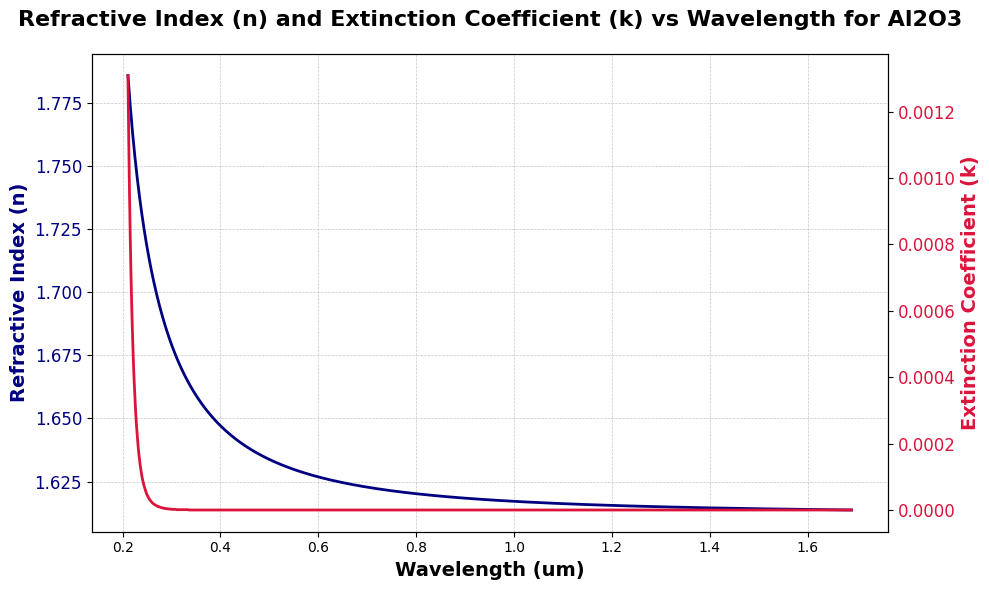

In [ ]:
visualize_material_properties(material_name = "Al2O3")

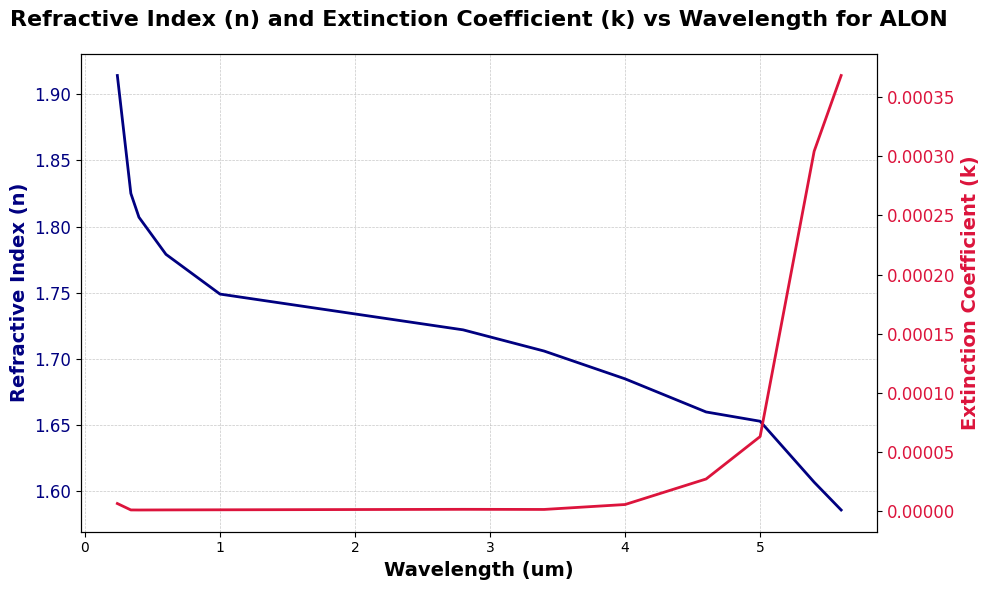

In [ ]:
visualize_material_properties(material_name = "ALON")

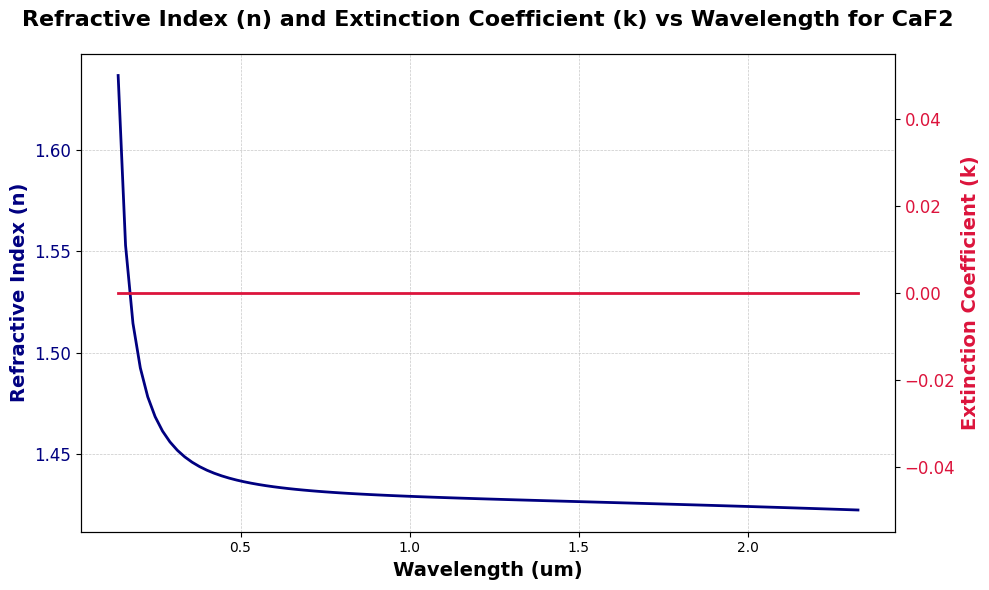

In [ ]:
visualize_material_properties(material_name = "CaF2")

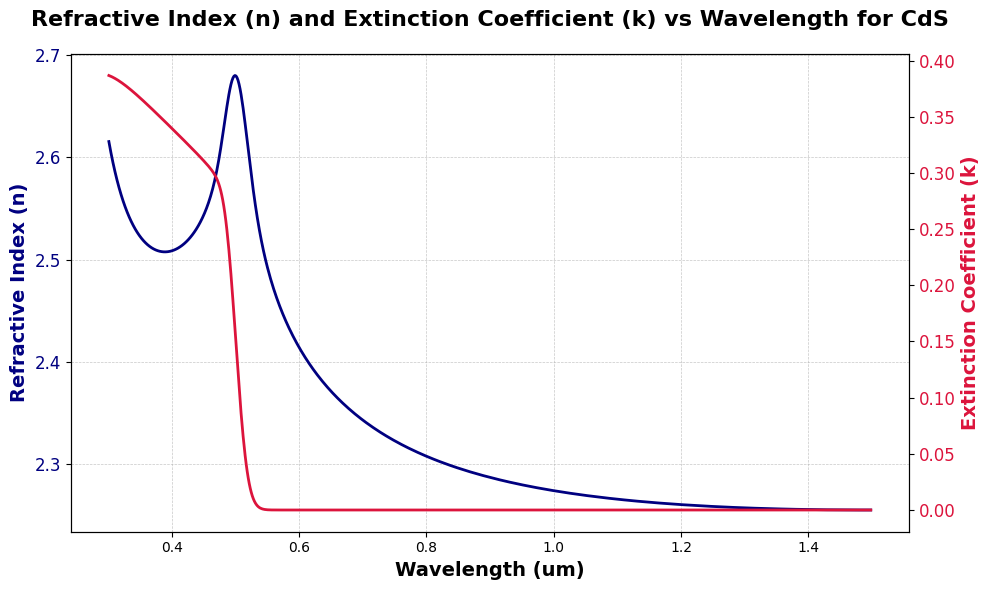

In [ ]:
visualize_material_properties(material_name = "CdS")

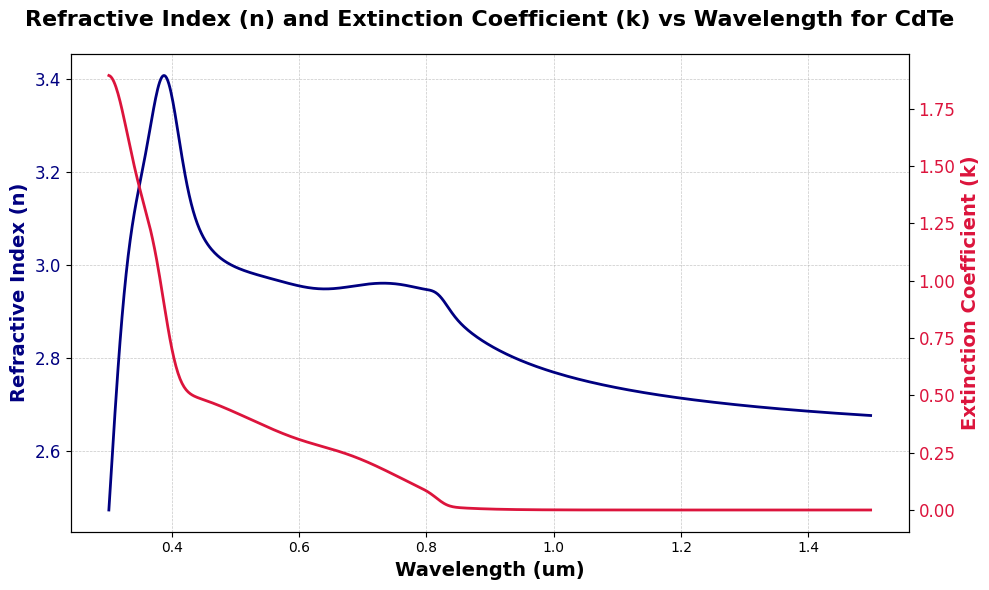

In [ ]:
visualize_material_properties(material_name = "CdTe")

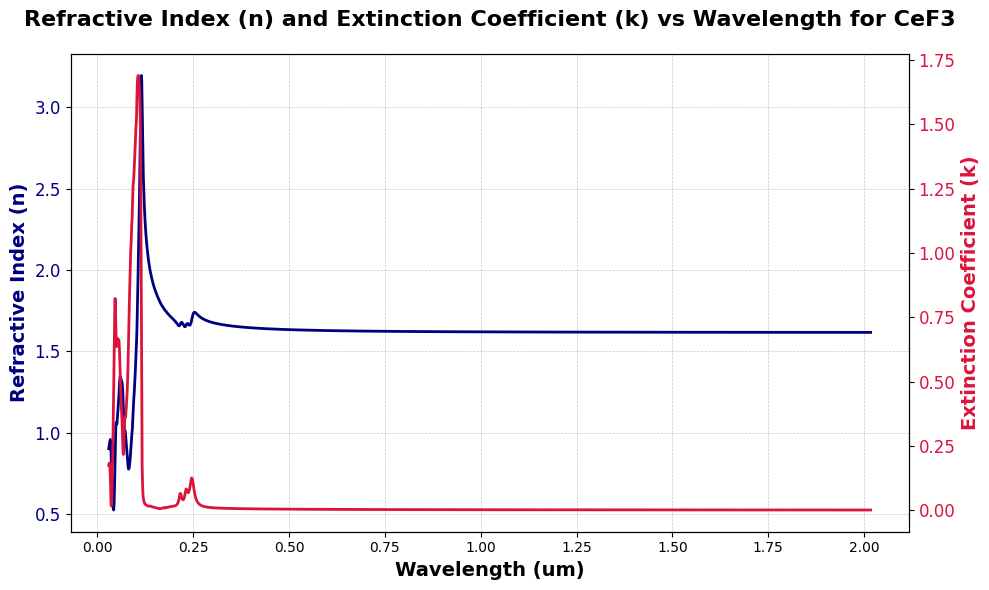

In [ ]:
visualize_material_properties(material_name = "CeF3")

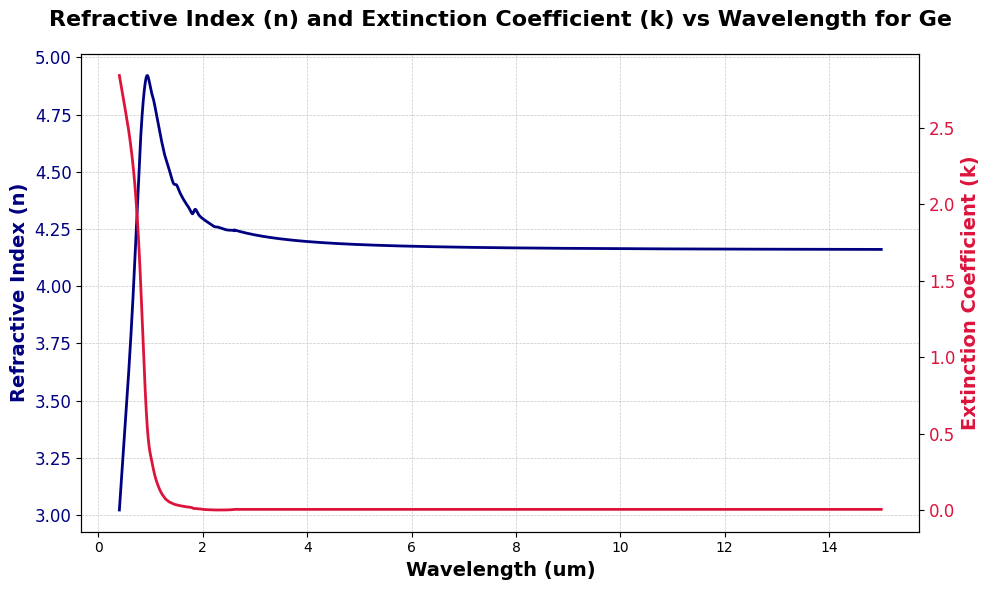

In [ ]:
visualize_material_properties(material_name = "Ge")

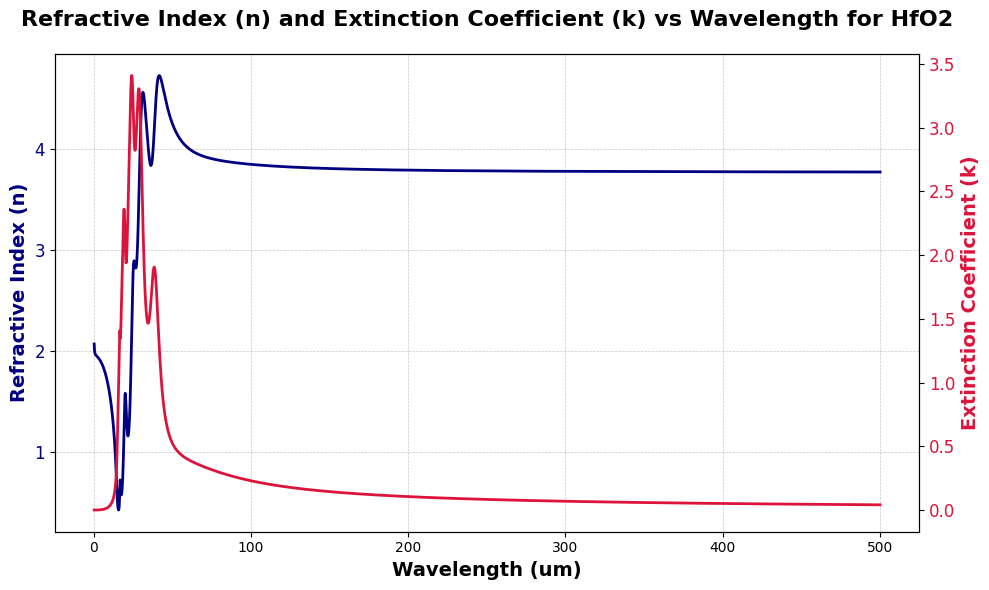

In [ ]:
visualize_material_properties(material_name = "HfO2")

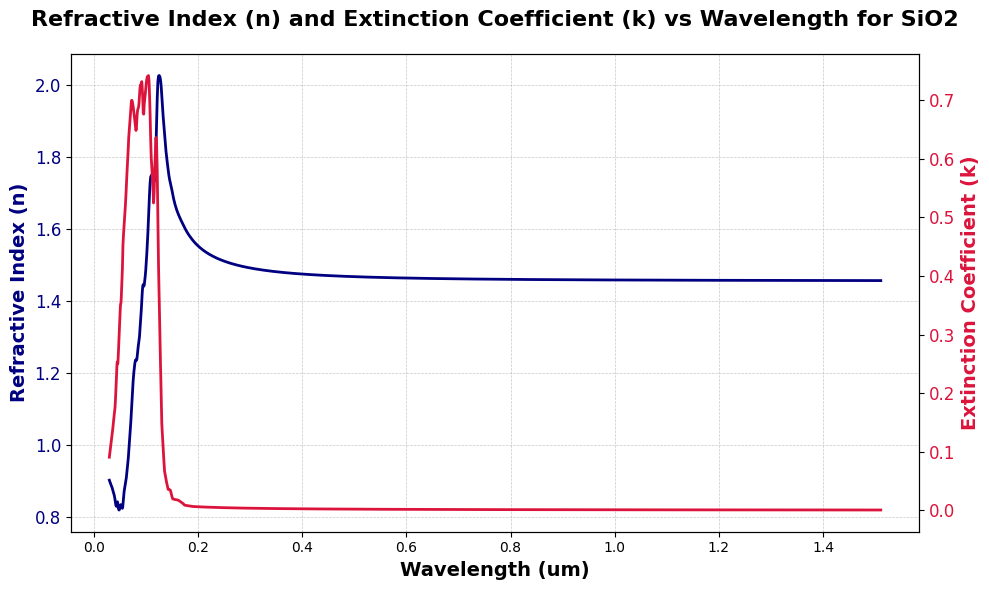

In [ ]:
visualize_material_properties(material_name = "SiO2")

 ### **Logarithmic Scale Axis**

Either axis can be converted to a logarithmic scale using the `logX` and `logY ` flags.

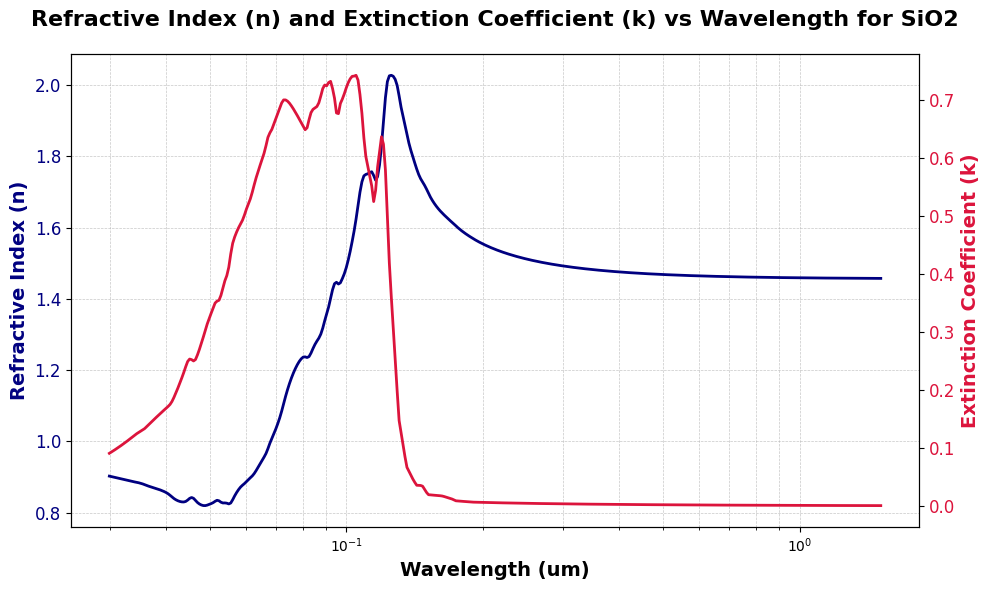

In [ ]:
visualize_material_properties(material_name = "SiO2", logX = True, logY = False)

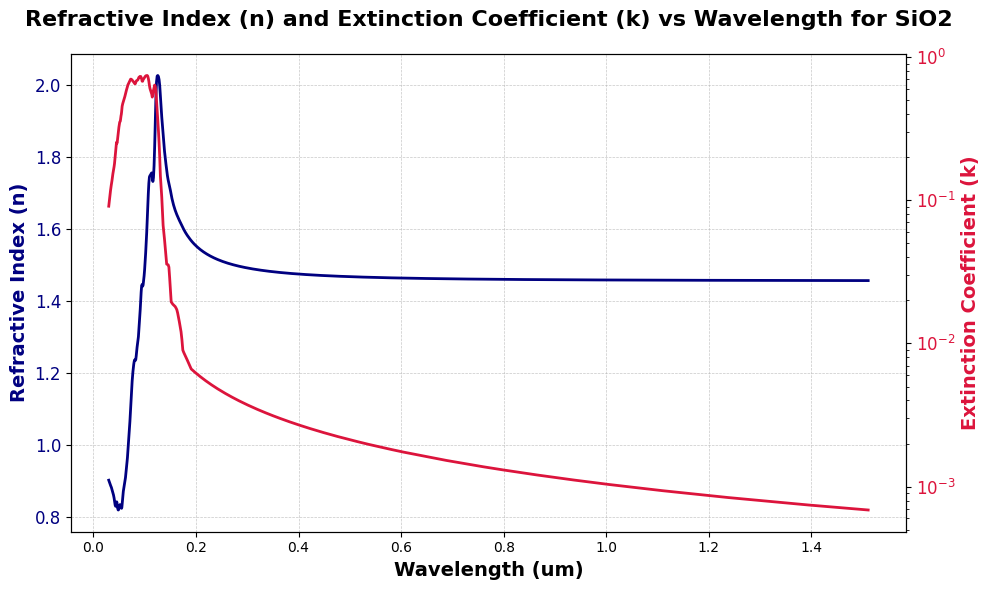

In [ ]:
visualize_material_properties(material_name = "SiO2", logX = False, logY = True)

 ### **Refractive Index and Extinction Coefficient as a Function of Photon Energy**

You can also display the x-axis in terms of photon energy instead of wavelength. To do this, simply enable the `eV` flag.

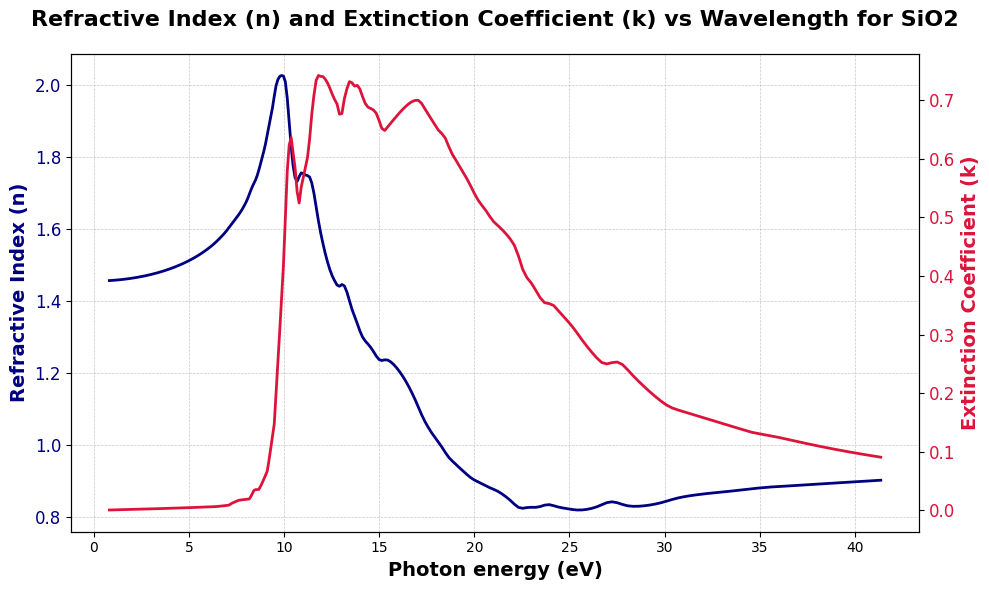

In [ ]:
visualize_material_properties(material_name = "SiO2", logX = False, logY = False, eV = True)

 ### **Saving Plot**

If you want to save the plot of this data, set `savefig = True` and then provide the folder name as a string to `save_path`. Please do not enter the full path.

Figure saved successfully at: material_info/SiO2_data/SiO2_nk_plot.png


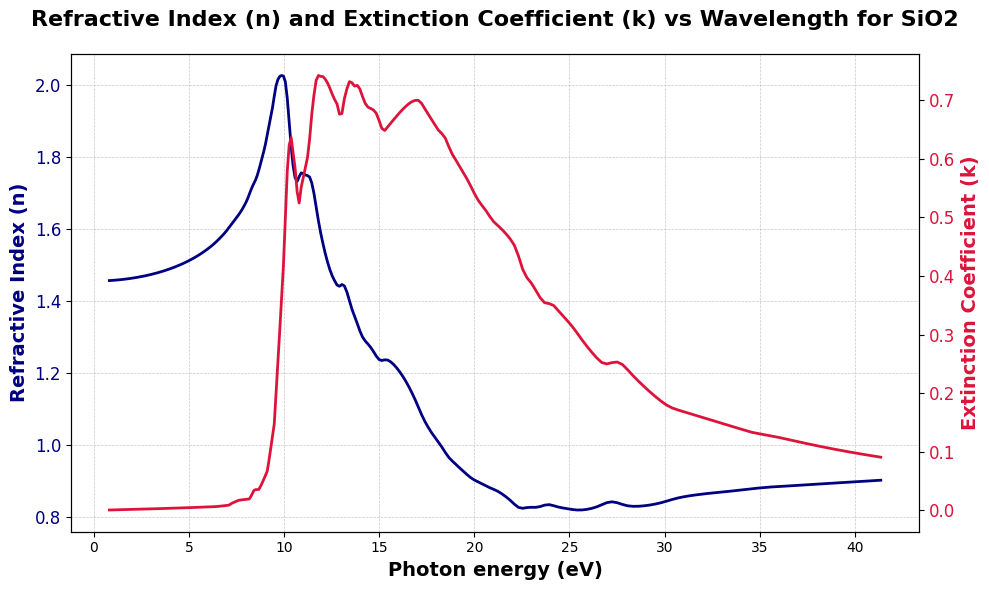

In [ ]:
visualize_material_properties(material_name = "SiO2", logX = False, logY = False, eV = True, savefig = True, save_path = "material_info/SiO2_data")

# **Adding Refractive Index and Extinction Coefficient Data to Material Database**

### **Importing Libraries**

Importing `visualize_material_properties` function from `tmmax.data` is sufficient for data visualizations.

In [ ]:
import jax.numpy as jnp
from jax import jit
from tmmax.data import add_material_to_nk_database

### **Creating Dummy n, k Data Generator Function**

Here, I created a function that generates n and k data for a dummy material. In your case, this is not necessary—you can directly use your own n and k data.

In [ ]:
@jit
def dummy_material_n_k(wavelength_um):
    """
    Calculate refractive index and extinction coefficient for dummy material

    Args:
        wavelength_um: Wavelength in micrometers (1.5-1.6 um range)

    Returns:
        n: Refractive index
        k: Extinction coefficient
    """
    # Create a fake wavelength-dependent refractive index with some features
    n_base = 3.2
    n_peak = 0.15 * jnp.exp(-((wavelength_um - 1.55) / 0.02)**2)
    n = n_base + n_peak

    # Create a fake wavelength-dependent extinction coefficient
    k_base = 0.001
    k_peak = 0.0005 * jnp.exp(-((wavelength_um - 1.53) / 0.03)**2)
    k = k_base + k_peak

    return n, k

Creating dummy_n and dummy_k data arrays.

In [ ]:
dummy_wavelengths = jnp.linspace(1.5, 1.6, 100)
dummy_n, dummy_k = dummy_material_n_k(dummy_wavelengths)

### **Adding Materials to the Database**

The following line adds a new material named `'dummy_material'` to the internal `n-k` database. It takes four arguments:  
- `wavelength_arr`: an array of wavelength values,  
- `refractive_index_arr`: an array representing the real part of the refractive index (`n`),  
- `extinction_coeff_arr`: an array representing the imaginary part (`k`),  
- `material_name`: the name of the material to be added.

In this example, dummy data (`dummy_wavelengths`, `dummy_n`, and `dummy_k`) is used to simulate a material entry. In practice, you can replace these arrays with your actual `n` and `k` data.


In [ ]:
add_material_to_nk_database(wavelength_arr = dummy_wavelengths,
                            refractive_index_arr = dummy_n,
                            extinction_coeff_arr = dummy_k,
                            material_name='dummy_material')

'dummy_material.csv' recreated successfully.


### **Plotting the Material Data**

You can directly plot the materials you've added to the database using visualize_material_properties.

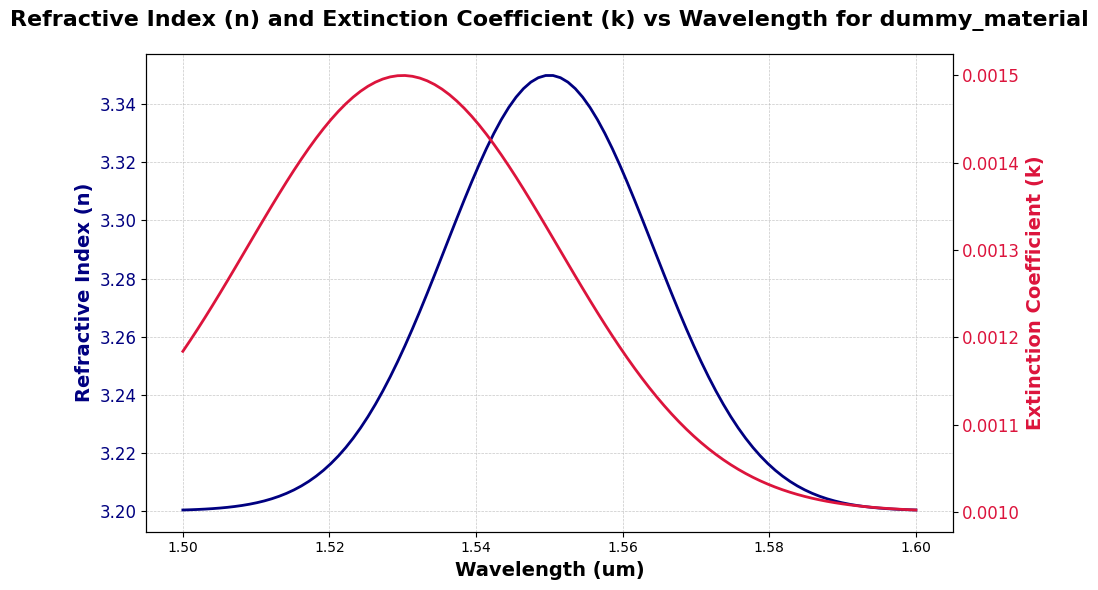

In [ ]:
visualize_material_properties(material_name = "dummy_material")

# **Reflectance Performance of the W-coat on a Glass Substrate**

### **Introduction**

We will use the Transfer Matrix Method (TMM) to analyze the reflection behavior of this multilayer thin film. The W-coat consists of two layers made from Magnesium Fluoride (MgF₂) and Yttrium Oxide (Y₂O₃). These layers are stacked on a glass substrate (Silicon Dioxide, SiO₂), and the incident medium is air.

![title](../_static/stack_of_w_coat.png)

In this example, the calculation is done for two polarizations:
- **s-polarization**: Electric field perpendicular to the plane of incidence.
- **p-polarization**: Electric field parallel to the plane of incidence.

We will calculate the reflectance as a function of wavelength and angle of incidence for each polarization.


### **Materials and Layer Thickness**

We are considering the following material stack:

- **Air** as the incident medium.
- **MgF₂ (Magnesium Fluoride)** with a thickness of 93 nm.
- **Y₂O₃ (Yttrium Oxide)** with a thickness of 63 nm.
- **SiO₂ (Silicon Dioxide)** as the substrate.

These materials are well-suited for anti-reflection coatings and optical filters due to their refractive indices.

---

In [ ]:
from tmmax.tmm import tmm

# Define the materials and their thicknesses
material_list =  ["Air", "MgF2", "Y2O3", "SiO2"]
thickness_list = jnp.array([93e-9, 63e-9])

# Define the wavelength range (500 nm to 700 nm) and angles of incidence (0° to 70°)
wavelength_arr = jnp.linspace(500e-9, 700e-9, 1000)
angle_of_incidences = jnp.linspace(0, (70*jnp.pi/180), 1000)

# Calculate reflectance for s-polarization
result_s = tmm(material_list=material_list, thickness_list=thickness_list,
             wavelength_arr=wavelength_arr, angle_of_incidences=angle_of_incidences,
             polarization="s")

# Calculate reflectance for p-polarization
result_p = tmm(material_list=material_list, thickness_list=thickness_list,
             wavelength_arr=wavelength_arr, angle_of_incidences=angle_of_incidences,
             polarization="p")

### **Visualization of Results**

We will now visualize the reflectance, transmittance and absorbance for both s-polarization and p-polarization as a function of wavelength and angle of incidence. The color map will represent the reflectance percentage.

### **Reflectance Results**

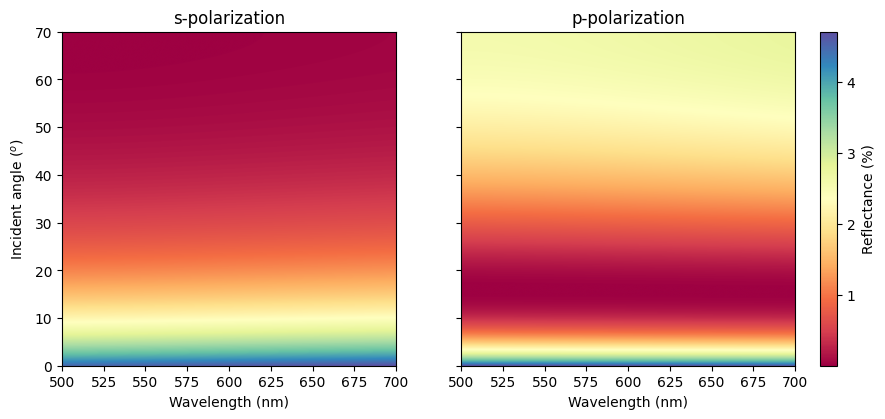

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[0]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[0]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Reflectance (%)')

plt.savefig("w_coat_reflectance_s_p.png", dpi=600)
plt.show()

### **Transmittance Results**

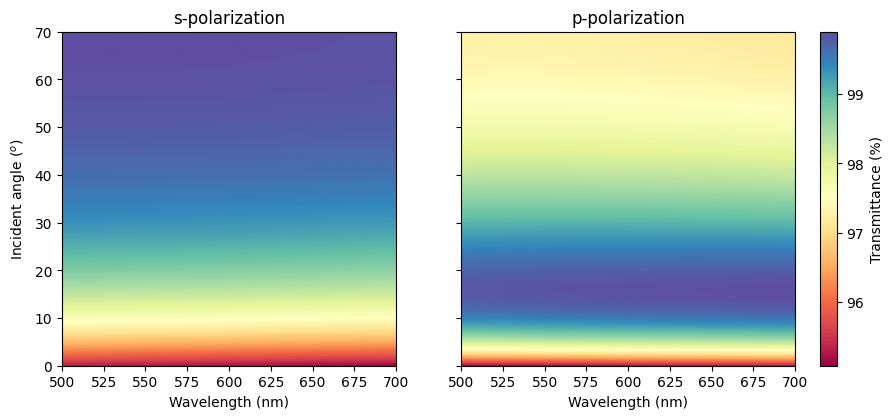

In [ ]:
# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[1]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[1]*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Transmittance (%)')

plt.savefig("w_coat_transmittance_s_p.png", dpi=600)
plt.show()

### **Absorbance Results**

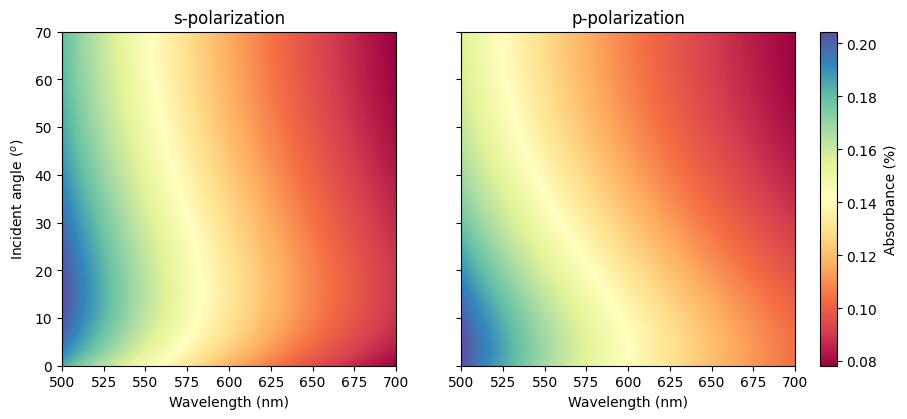

In [ ]:
# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow((1 -result_s[0] - result_s[1])*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow((1 -result_p[0] - result_p[1])*100, cmap='Spectral', aspect=200/70,extent = [500, 700, 0, 70])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Absorbance (%)')

plt.savefig("w_coat_absorbance_s_p.png", dpi=600)
plt.show()

# **50:50 Beam Splitter**

This notebook demonstrates how to calculate the reflectance of a multilayer thin-film stack designed as a 50:50 beam splitter deposited on a glass substrate. The reflectance is computed for both s-polarization and p-polarization across a wavelength range of 525 nm to 575 nm, and for incident angles from 0° to 10°.

### **Introduction**

We will use the Transfer Matrix Method (TMM) to analyze the reflectance and transmittance of a multilayer thin-film structure designed to function as a 50:50 beam splitter in the visible spectrum. The multilayer consists of alternating layers of Titanium Dioxide (TiO₂) and Silicon Dioxide (SiO₂) deposited on a glass substrate, with air as the incident medium.

![title](../_static/stack_of_beam_splitter.png)

In this example, the calculation is done for two polarizations:
- **s-polarization**: Electric field perpendicular to the plane of incidence.
- **p-polarization**: Electric field parallel to the plane of incidence.

We will calculate the reflectance as a function of wavelength and angle of incidence for each polarization.

---

### **Materials and Layer Thickness**

We are considering the following material stack:

- **Air** as the incident medium.
- **TiO₂ (Titanium Dioxide)** with a thickness of 58.5 nm.
- **SiO₂ (Silicon Dioxide)** with a thickness of 94.8 nm.
- **SiO₂ (Silicon Dioxide)** as the glass substrate.



In [ ]:
# Define the materials and their thicknesses
material_list =  ["Air", "TiO2", "SiO2","TiO2","SiO2","TiO2","SiO2","TiO2", "SiO2"]
thickness_list = jnp.array([58.5e-9, 94.8e-9,58.5e-9, 94.8e-9,58.5e-9, 94.8e-9,58.5e-9])

# Define the wavelength range (525 nm to 575 nm) and angles of incidence (0° to 10°)
wavelength_arr = jnp.linspace(525e-9, 575e-9, 1000)
angle_of_incidences = jnp.linspace(0, (10*jnp.pi/180), 1000)

# Calculate reflectance for s-polarization
result_s = tmm(material_list=material_list, thickness_list=thickness_list,
             wavelength_arr=wavelength_arr, angle_of_incidences=angle_of_incidences,
             polarization="s")

# Calculate reflectance for p-polarization
result_p = tmm(material_list=material_list, thickness_list=thickness_list,
             wavelength_arr=wavelength_arr, angle_of_incidences=angle_of_incidences,
             polarization="p")

### **Reflectance Results**

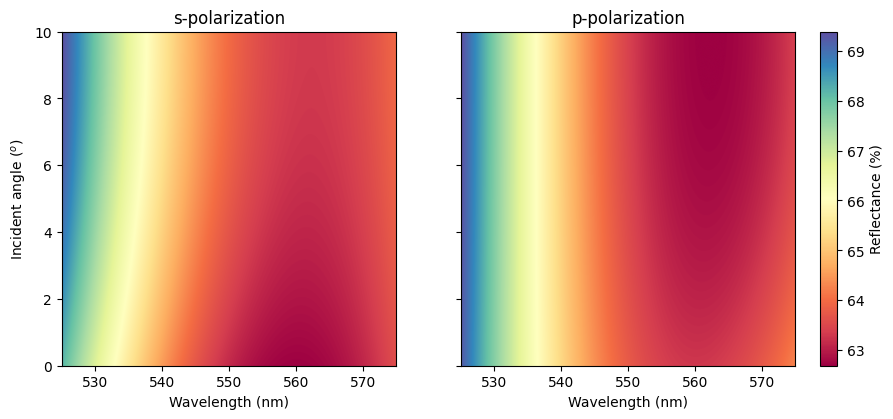

In [ ]:
# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[1]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[1]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Reflectance (%)')

plt.savefig("beam_splitter_reflectance_s_p.png", dpi=600)
plt.show()

### **Transmittance Results**

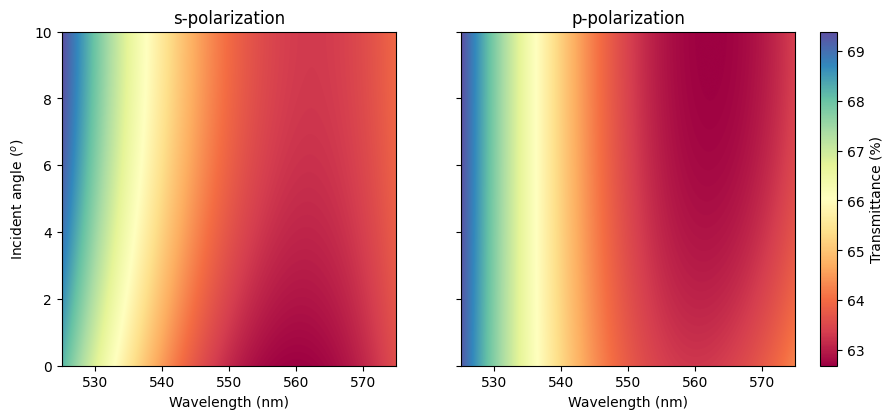

In [ ]:
# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow(result_s[1]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow(result_p[1]*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Transmittance (%)')

plt.savefig("beam_splitter_transmittance_s_p.png", dpi=600)
plt.show()

### **Absorbance Results**

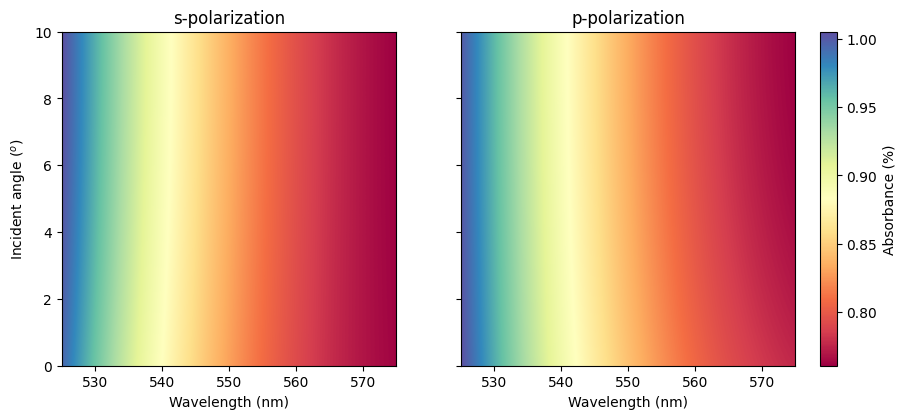

In [ ]:
# Set up figure and image grid
fig = plt.figure(figsize=(10, 5))

grid = ImageGrid(fig, 111,
                 nrows_ncols=(1,2),
                 axes_pad=0.65,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="5%",
                 cbar_pad=0.25,
                 )

# Add data to image grid
i = 0
for ax in grid:
    if i == 0:
        im = ax.imshow((1 -result_s[0] - result_s[1])*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("s-polarization")
    if i ==1:
        im = ax.imshow((1 -result_p[0] - result_p[1])*100, cmap='Spectral', aspect=50/10,extent = [525, 575, 0, 10])
        ax.set_title("p-polarization")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Incident angle ($^o$)")
    i += 1

# Colorbar
ax.cax.colorbar(im, label='Absorbance (%)')

plt.savefig("beam_splitter_absorbance_s_p.png", dpi=600)
plt.show()